In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#Importing data
df = pd.read_csv("USA_Housing.csv")
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


## Data Preparation

### Data separation as X and y

In [3]:
#Obtaining the 'y' variable
y = df['Price']
y

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 5000, dtype: float64

In [4]:
col = list(df.columns)
col_length = len(col)

In [5]:
y = df[col[col_length-2]]
y

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 5000, dtype: float64

In [6]:
X = df.drop(["Price","Address"], axis=1)
X

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035
4996,78491.275435,6.999135,6.576763,4.02,25616.115489
4997,63390.686886,7.250591,4.805081,2.13,33266.145490
4998,68001.331235,5.534388,7.130144,5.44,42625.620156


### Data Splitting

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [8]:
X_train

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
4036,74279.926228,6.929481,7.369607,5.40,26947.152504
2883,56957.835209,5.969854,5.935709,2.05,29498.964187
4162,77453.479788,5.909818,7.640186,3.02,53100.278674
4640,77906.185182,6.537044,9.458466,3.08,31399.756830
2430,62472.158580,6.704512,7.665173,6.48,37618.676554
...,...,...,...,...,...
1593,71920.678777,6.726673,7.614547,6.17,26341.095572
4060,69686.320170,5.367355,8.329115,5.41,41007.660003
1346,48362.981952,6.151660,8.252002,4.19,49354.129732
3454,72029.312855,7.072146,5.378450,3.41,42143.262812


In [9]:
X_test

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
2648,63824.394539,4.991750,5.003836,4.00,40086.458749
2456,67041.967661,6.021458,5.346830,3.39,15633.099048
4557,75571.044023,6.114928,7.318214,4.44,33988.435859
4884,64204.720644,4.862155,7.714891,6.21,46157.439165
92,70805.610684,4.443729,5.809147,3.30,29268.826742
...,...,...,...,...,...
3014,65629.880975,6.418472,7.524875,6.19,17609.196932
734,76870.356285,5.359764,5.892954,4.32,25655.867123
452,80008.667831,4.847002,8.672979,5.41,45889.890487
2558,60317.776991,3.516438,7.033852,3.42,32276.034269


## Model Building

### Linear Regression

#### >Training the model

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

#### >Applying the model to make a prediction

In [12]:
y_lr_train_pred = lr.predict(X_train)
y_lr_train_pred

array([1423135.94121491,  747864.15237165, 1746060.15637412, ...,
       1177283.3556191 , 1386041.61905158, 1365722.19315693])

In [13]:
y_lr_test_pred = lr.predict(X_test)
y_lr_test_pred

array([ 791123.50601188,  697223.19909089, 1414478.55192483, ...,
       1646511.06160945,  592560.955015  ,  979949.89008304])

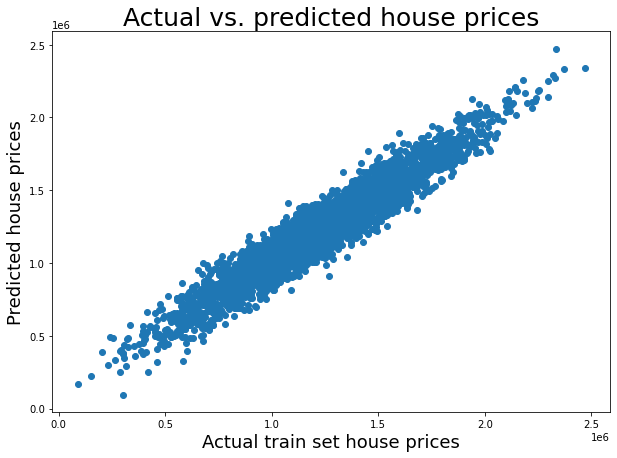

In [23]:
plt.figure(figsize=(10,7))
plt.title("Actual vs. predicted house prices",fontsize=25)
plt.xlabel("Actual train set house prices",fontsize=18)
plt.ylabel("Predicted house prices", fontsize=18)
plt.scatter(x=y_train,y=y_lr_train_pred)
#plt.show

## Evaluate Model Performance

In [14]:
y_train

4036    1.422004e+06
2883    7.835651e+05
4162    1.664148e+06
4640    1.639099e+06
2430    1.463443e+06
            ...     
1593    1.134055e+06
4060    1.148508e+06
1346    1.035126e+06
3454    1.205879e+06
3582    1.404622e+06
Name: Price, Length: 3500, dtype: float64

In [15]:
y_lr_train_pred

array([1423135.94121491,  747864.15237165, 1746060.15637412, ...,
       1177283.3556191 , 1386041.61905158, 1365722.19315693])

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [17]:
print('Lr MSE (train):', lr_train_mse)
print('Lr r2 (train):', lr_train_r2)
print('Lr MSE (test):', lr_test_mse)
print('Lr r2 (test):', lr_test_r2)

Lr MSE (train): 10110916859.639553
Lr r2 (train): 0.917328958797942
Lr MSE (test): 10489638335.804985
Lr r2 (test): 0.9193832647798634


In [18]:
lr_results = pd.DataFrame(['Linear regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method', 'Training MSE','Training R2', 'Test MSE', 'Test R2']

In [19]:
lr_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear regression,10110916859.639553,0.917329,10489638335.804985,0.919383
